# Open in Colab
<a target="_blank" href="https://colab.research.google.com/github/Nicolepcx/ai-agents-the-definitive-guide/blob/main/CH11/ch11_memoizing_swarm_research_engine.ipynb">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>


## Swarm Research Engine  — Progress-Aware + Synthesis

A multi-agent research system that produces conclusions.

What we do:

  1. PROGRESS GUARD. The graph tracks facts-before and facts-after each
     tool call. If a tool added 0 new facts, the agent is penalized from
     choosing the same tool again, and after 2 consecutive no-progress
     steps it is forced to DONE or SYNTHESIZE.

  2. SYNTHESIS NODE. When the planner chooses DONE (or is forced there),
     a separate LLM call produces a final threat assessment with:
       - verdict (low / medium / high / critical)
       - confidence score
       - supporting evidence (cited facts)
       - gaps (what's still unknown)
     This makes the system a research engine, not just a navigation loop.

  3. CONTENT-HASHED SEARCH FACTS. Search results are keyed by a content
     hash, not positional labels. Fact("search_<hash8>", snippet, ...).
     This means identical search results deduplicate regardless of order,
     and different results never collide.

  4. HONEST METRICS. Cache hits are classified as:
       - productive_hits: cache hit on a state that differs from the
         previous step (the agent had genuinely new information)
       - stale_hits: cache hit on the same state as last step
         (the agent is looping — this is waste, not savings)
       - no_progress_steps: tool calls that added 0 new facts
     The report shows these separately so you can see real efficiency
     vs. looping-that-looks-like-efficiency.

  5. STATE-CHANGE-AWARE ROUTING. If the fact set hasn't changed since
     the prior step, the graph forces a different tool or terminates.

In [ ]:
!pip install langchain_openai

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.7/88.7 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 515.1/515.1 kB 14.1 MB/s eta 0:00:00
  Attempting uninstall: langchain-core
    Found existing installation: langchain-core 1.2.28
    Uninstalling langchain-core-1.2.28:
      Successfully uninstalled langchain-core-1.2.28


In [ ]:
import os
from dotenv import load_dotenv


load_dotenv()


OPENROUTER_API_KEY = os.getenv("OPENROUTER_API_KEY")
OPENAI_API_KEY = os.getenv("OPENAI_API_KEY")
TAVILY_API_KEY = os.getenv("TAVILY_API_KEY")

MODEL = "gpt-5.4-nano"


In [ ]:


from __future__ import annotations

import hashlib
import json
import logging
import os
import sys
import time
from dataclasses import dataclass, field
from enum import Enum
from typing import Any, TypedDict

import numpy as np
import requests
from tenacity import (
    retry,
    stop_after_attempt,
    wait_exponential,
    retry_if_exception_type,
    before_sleep_log,
)

from langchain_openai import OpenAIEmbeddings
from langgraph.graph import StateGraph, END


# ============================================================
# Config
# ============================================================

@dataclass(frozen=True)
class SwarmConfig:
    openrouter_api_key: str
    tavily_api_key: str
    openai_api_key: str
    model: str = "gpt-5.4-nano"
    embed_model: str = "text-embedding-3-small"
    similarity_threshold: float = 0.90
    openrouter_base_url: str = "https://openrouter.ai/api/v1/chat/completions"
    tavily_base_url: str = "https://api.tavily.com/search"
    llm_timeout: int = 30
    search_timeout: int = 15
    search_depth: str = "advanced"
    search_max_results: int = 3
    max_steps_per_agent: int = 6
    max_no_progress: int = 2        # consecutive 0-new-fact steps before forced DONE
    estimated_cost_per_call: float = 0.02

    @classmethod
    def from_env(cls) -> SwarmConfig:
        def _req(var: str) -> str:
            val = os.environ.get(var, "")
            if not val:
                raise EnvironmentError(f"{var} is not set")
            return val
        return cls(
            openrouter_api_key=_req("OPENROUTER_API_KEY"),
            tavily_api_key=_req("TAVILY_API_KEY"),
            openai_api_key=_req("OPENAI_API_KEY"),
            model=os.environ.get("SWARM_MODEL", "gpt-5.4-nano"),
            embed_model=os.environ.get("SWARM_EMBED_MODEL", "text-embedding-3-small"),
            similarity_threshold=float(os.environ.get("SWARM_SIM_THRESHOLD", "0.90")),
            max_steps_per_agent=int(os.environ.get("SWARM_MAX_STEPS", "6")),
        )


# ============================================================
# Logging
# ============================================================

def _setup_logger(name: str = "swarm") -> logging.Logger:
    level_str = os.environ.get("SWARM_LOG_LEVEL", "INFO").upper()
    level = getattr(logging, level_str, logging.INFO)
    logger = logging.getLogger(name)
    logger.setLevel(level)
    if not logger.handlers:
        h = logging.StreamHandler(sys.stderr)
        h.setLevel(level)
        h.setFormatter(logging.Formatter(
            "[%(asctime)s] %(levelname)-8s %(name)s  %(message)s", datefmt="%H:%M:%S"))
        logger.addHandler(h)
    return logger

log = _setup_logger()


# ============================================================
# Structured Facts
# ============================================================

@dataclass(frozen=True, eq=False)
class Fact:
    """Typed key-value observation. timestamp is metadata (excluded from
    hash/eq) so identical observations re-captured at different times still
    count as duplicates."""
    key: str
    value: Any
    source: str = "unknown"
    confidence: float = 1.0
    timestamp: float = field(default_factory=time.time)

    def __hash__(self) -> int:
        return hash((self.key, self._stable_value(), self.source, self.confidence))

    def __eq__(self, other: object) -> bool:
        if not isinstance(other, Fact):
            return NotImplemented
        return (self.key == other.key
                and self._stable_value() == other._stable_value()
                and self.source == other.source
                and self.confidence == other.confidence)

    def _stable_value(self) -> str:
        if isinstance(self.value, (dict, list)):
            return json.dumps(self.value, sort_keys=True)
        return str(self.value)

    def canonical_key(self) -> str:
        return self.key.lower().strip().replace(" ", "_").replace("-", "_")

    def canonical_value(self) -> str:
        if isinstance(self.value, (int, float)):
            return str(self.value)
        if isinstance(self.value, str):
            v = self.value.strip().replace(",", "").replace("$", "").replace("€", "")
            try:
                v = str(float(v))
            except ValueError:
                pass
            return v.lower()
        return json.dumps(self.value, sort_keys=True)

    def to_text(self) -> str:
        return f"{self.key}: {self.value}"

    def to_dict(self) -> dict[str, Any]:
        return {"key": self.key, "value": self.value, "source": self.source,
                "confidence": self.confidence, "timestamp": self.timestamp}

    def __repr__(self) -> str:
        return f"Fact({self.key!r}={self.value!r})"


# ============================================================
# WorldView — snapshot with evidence depth
# ============================================================

@dataclass(frozen=True)
class WorldView:
    """Snapshot of FactStore: current values + per-key evidence summary.

    `evidence` is a tuple of (canonical_key, sorted source tuple, distinct
    value count). distinct_values > 1 means the store has seen disagreeing
    values for that key — the world is not internally consistent.
    """
    current: frozenset[Fact]
    evidence: tuple[tuple[str, tuple[str, ...], int], ...]

    @classmethod
    def from_history(cls, history: dict[str, list[Fact]]) -> "WorldView":
        current, evidence = [], []
        for ck in sorted(history):
            h = history[ck]
            current.append(max(h, key=lambda f: (f.timestamp, f.confidence)))
            sources = tuple(sorted({f.source for f in h}))
            n_distinct = len({f.canonical_value() for f in h})
            evidence.append((ck, sources, n_distinct))
        return cls(frozenset(current), tuple(evidence))

    @classmethod
    def from_facts(cls, facts: frozenset[Fact]) -> "WorldView":
        groups: dict[str, list[Fact]] = {}
        for f in facts:
            groups.setdefault(f.canonical_key(), []).append(f)
        return cls.from_history(groups)


# ============================================================
# Shared Fact Store
# ============================================================

class FactStore:
    """Shared blackboard with per-key history.

    add() returns one of:
      added       — new canonical key
      reinforced  — same value, new source (extra evidence, no view change)
      conflict    — same key, different value (world disagrees)
      duplicate   — exact restatement (no information gained)

    version bumps on added | reinforced | conflict — those are the
    state-change events the planner should react to.
    """

    def __init__(self):
        self._history: dict[str, list[Fact]] = {}
        self._version: int = 0
        self.stats = {"added": 0, "reinforced": 0, "conflict": 0, "duplicate": 0}

    def add(self, fact: Fact) -> str:
        ck = fact.canonical_key()
        if ck not in self._history:
            self._history[ck] = [fact]
            self._version += 1
            self.stats["added"] += 1
            return "added"
        history = self._history[ck]
        new_val = fact.canonical_value()
        existing_pairs = {(f.canonical_value(), f.source) for f in history}
        if (new_val, fact.source) in existing_pairs:
            self.stats["duplicate"] += 1
            return "duplicate"
        history.append(fact)
        existing_vals = {f.canonical_value() for f in history[:-1]}
        if new_val in existing_vals:
            self._version += 1
            self.stats["reinforced"] += 1
            return "reinforced"
        self._version += 1
        self.stats["conflict"] += 1
        return "conflict"

    def add_many(self, facts: list[Fact]) -> dict[str, int]:
        counts = {"added": 0, "reinforced": 0, "conflict": 0, "duplicate": 0}
        for f in facts:
            counts[self.add(f)] += 1
        return counts

    @staticmethod
    def _current_for(history: list[Fact]) -> Fact:
        # Policy: freshest timestamp wins, tiebreak by confidence.
        return max(history, key=lambda f: (f.timestamp, f.confidence))

    def current(self, canonical_key: str) -> Fact | None:
        h = self._history.get(canonical_key)
        return self._current_for(h) if h else None

    def get_all(self) -> frozenset[Fact]:
        return frozenset(self._current_for(h) for h in self._history.values())

    def get_keys(self) -> set[str]:
        return set(self._history.keys())

    def conflicts(self) -> dict[str, list[Fact]]:
        return {ck: list(h) for ck, h in self._history.items()
                if len({f.canonical_value() for f in h}) > 1}

    def snapshot(self) -> WorldView:
        return WorldView.from_history(self._history)

    @property
    def version(self) -> int:
        """Bumps on added | reinforced | conflict — the events that change
        what the planner should consider."""
        return self._version

    def __len__(self) -> int:
        return len(self._history)


# ============================================================
# Tool-level cache
# ============================================================

class ToolCache:
    def __init__(self):
        self._cache: dict[str, list[Fact]] = {}
        self.stats = {"hits": 0, "misses": 0}

    def _key(self, tool: str, kwargs: dict[str, Any]) -> str:
        raw = json.dumps({"tool": tool, **kwargs}, sort_keys=True)
        return hashlib.sha256(raw.encode()).hexdigest()[:16]

    def get(self, tool: str, kwargs: dict[str, Any]) -> list[Fact] | None:
        k = self._key(tool, kwargs)
        if k in self._cache:
            self.stats["hits"] += 1
            log.info("  TOOLCACHE HIT  %s(%s)", tool, kwargs)
            return self._cache[k]
        self.stats["misses"] += 1
        return None

    def store(self, tool: str, kwargs: dict[str, Any], facts: list[Fact]) -> None:
        self._cache[self._key(tool, kwargs)] = facts


# ============================================================
# PlannerContext — full conditioning context for the cache key
# ============================================================

@dataclass(frozen=True)
class PlannerContext:
    """Everything the planner LLM is conditioned on. The cache key must
    cover all four — keying only on (task, facts) lets a cached DONE
    made under stale-tool pressure get replayed by a fresh agent that
    has no stale tools, bypassing the anti-looping signal."""
    task: str
    view: WorldView
    tools_available: tuple[str, ...]   # sorted
    stale_tools: tuple[str, ...]       # sorted, () if none

    @classmethod
    def make(cls, task: str, view: WorldView,
             tools_available: list[str],
             stale_tools: list[str] | None) -> "PlannerContext":
        return cls(
            task=task,
            view=view,
            tools_available=tuple(sorted(tools_available)),
            stale_tools=tuple(sorted(stale_tools or ())),
        )


# ============================================================
# Tiered planner cache
# ============================================================

@dataclass
class _CacheEntry:
    fact_hash: str
    normalized_hash: str
    full_vec: np.ndarray
    fact_count: int
    decision: dict[str, Any]
    fact_keys: frozenset[str]
    tools_available: tuple[str, ...]   # context guard
    stale_tools: tuple[str, ...]       # context guard


class TieredCache:
    """Exact → Normalized → Semantic, tracked separately. All three layers
    derive from the full PlannerContext (task + facts + evidence + tools +
    stale tools). Semantic tier additionally enforces an exact match on
    stale_tools/tools_available, since a high cosine similarity on the
    fact view alone is not enough to prove the planner's anti-looping
    constraints are equivalent."""

    def __init__(self, embeddings: OpenAIEmbeddings, threshold: float = 0.90):
        self.embeddings = embeddings
        self.threshold = threshold
        self._entries: list[_CacheEntry] = []
        self.stats = {
            "exact_hits": 0, "normalized_hits": 0, "semantic_hits": 0,
            "misses": 0, "comparisons": 0,
            # entries that were semantically close enough but rejected
            # because their planner context (tools/stale) didn't match
            "semantic_context_skips": 0,
        }

    @staticmethod
    def _evidence_parts(view: WorldView) -> list[str]:
        return [f"{ck}|{','.join(srcs)}|{n}" for ck, srcs, n in view.evidence]

    @staticmethod
    def _context_parts(ctx: "PlannerContext") -> list[str]:
        return [
            f"TASK:{ctx.task}",
            f"TOOLS:{','.join(ctx.tools_available)}",
            f"STALE:{','.join(ctx.stale_tools)}",
        ]

    @staticmethod
    def _exact_hash(ctx: "PlannerContext") -> str:
        parts_facts = sorted(f"{f.key}={f.value}" for f in ctx.view.current)
        raw = "||PCTX||".join([
            *TieredCache._context_parts(ctx),
            "FACTS", *parts_facts,
            "EV", *TieredCache._evidence_parts(ctx.view),
        ])
        return hashlib.sha256(raw.encode()).hexdigest()[:24]

    @staticmethod
    def _normalized_hash(ctx: "PlannerContext") -> str:
        parts_facts = sorted(
            f"{f.canonical_key()}={f.canonical_value()}" for f in ctx.view.current
        )
        raw = "||PCTX||".join([
            *TieredCache._context_parts(ctx),
            "FACTS", *parts_facts,
            "EV", *TieredCache._evidence_parts(ctx.view),
        ])
        return hashlib.sha256(raw.encode()).hexdigest()[:24]

    @staticmethod
    def _facts_to_text(ctx: "PlannerContext") -> str:
        parts = sorted(f.to_text() for f in ctx.view.current)
        ev_str = "; ".join(
            f"{ck}: {len(srcs)} source(s)" + (f", {n} distinct values" if n > 1 else "")
            for ck, srcs, n in ctx.view.evidence
        )
        tools = ",".join(ctx.tools_available) or "none"
        stale = ",".join(ctx.stale_tools) or "none"
        return (f"TASK: {ctx.task} | TOOLS_AVAILABLE: {tools} | STALE_TOOLS: {stale} | "
                f"FACTS: {' ; '.join(parts)} | EVIDENCE: {ev_str}")

    @staticmethod
    def _cosine(a: np.ndarray, b: np.ndarray) -> float:
        d = np.linalg.norm(a) * np.linalg.norm(b)
        return float(np.dot(a, b) / d) if d > 0 else 0.0

    def lookup(self, ctx: "PlannerContext") -> tuple[dict[str, Any] | None, str]:
        if not self._entries:
            self.stats["misses"] += 1
            return None, "miss"

        e_hash = self._exact_hash(ctx)
        n_hash = self._normalized_hash(ctx)
        facts = ctx.view.current

        for entry in self._entries:
            self.stats["comparisons"] += 1
            if entry.fact_hash == e_hash:
                self.stats["exact_hits"] += 1
                log.info("CACHE EXACT HIT")
                r = entry.decision.copy()
                r["_cache_tier"] = "exact"
                r["_cache_similarity"] = 1.0
                return r, "exact"

        for entry in self._entries:
            self.stats["comparisons"] += 1
            if entry.normalized_hash == n_hash:
                self.stats["normalized_hits"] += 1
                log.info("CACHE NORMALIZED HIT")
                r = entry.decision.copy()
                r["_cache_tier"] = "normalized"
                r["_cache_similarity"] = 1.0
                return r, "normalized"

        text = self._facts_to_text(ctx)
        query_vec = np.array(self.embeddings.embed_query(text), dtype=np.float32)
        n_facts = len(facts)
        best_sim, best_idx = -1.0, -1

        for i, entry in enumerate(self._entries):
            self.stats["comparisons"] += 1
            if abs(entry.fact_count - n_facts) > 1:
                continue
            # Hard guard: semantic similarity on facts is NOT enough — the
            # planner's anti-looping prompt depends on stale_tools and the
            # available tool set. Different conditioning → different decision
            # space → no cross-context reuse, even at high cosine sim.
            if (entry.stale_tools != ctx.stale_tools
                    or entry.tools_available != ctx.tools_available):
                self.stats["semantic_context_skips"] += 1
                continue
            sim = self._cosine(query_vec, entry.full_vec)
            if sim > best_sim:
                best_sim, best_idx = sim, i

        if best_idx >= 0 and best_sim >= self.threshold:
            self.stats["semantic_hits"] += 1
            entry = self._entries[best_idx]
            log.info("CACHE SEMANTIC HIT  sim=%.4f  query=%s  cached=%s  stale=%s",
                     best_sim, sorted(f.key for f in facts),
                     sorted(entry.fact_keys), list(ctx.stale_tools))
            r = entry.decision.copy()
            r["_cache_tier"] = "semantic"
            r["_cache_similarity"] = round(best_sim, 4)
            return r, "semantic"

        self.stats["misses"] += 1
        log.info("CACHE MISS  best_sim=%.4f  threshold=%.2f  stale=%s",
                 best_sim, self.threshold, list(ctx.stale_tools))
        return None, "miss"

    def store(self, ctx: "PlannerContext", decision: dict[str, Any]) -> None:
        text = self._facts_to_text(ctx)
        vec = np.array(self.embeddings.embed_query(text), dtype=np.float32)
        self._entries.append(_CacheEntry(
            fact_hash=self._exact_hash(ctx),
            normalized_hash=self._normalized_hash(ctx),
            full_vec=vec,
            fact_count=len(ctx.view.current),
            decision=decision,
            fact_keys=frozenset(f.canonical_key() for f in ctx.view.current),
            tools_available=ctx.tools_available,
            stale_tools=ctx.stale_tools,
        ))


# ============================================================
# Tool spec — single source of truth for the planner prompt AND
# the decision validator. The planner LLM is conditioned on this,
# so cache.store() must reject anything that doesn't satisfy it.
# ============================================================

TOOLS_SPEC: dict[str, dict[str, Any]] = {
    "search":       {"desc": "Web search for market intelligence",
                     "params": {"query": str}},
    "price":        {"desc": "Look up competitor MSRP pricing",
                     "params": {"company": str}},
    "sentiment":    {"desc": "Analyze market sentiment",
                     "params": {"topic": str}},
    "supply_chain": {"desc": "Check supply chain status",
                     "params": {"component": str}},
    "patent":       {"desc": "Search patent landscape",
                     "params": {"company": str}},
}


def _format_tool_params(params: dict[str, type]) -> str:
    return "{" + ", ".join(f"{k!r}: {t.__name__!r}" for k, t in params.items()) + "}"


def _validate_planner_decision(result: Any,
                               tools_available: list[str]) -> tuple[bool, str]:
    """Returns (is_valid, reason). Caller MUST NOT cache invalid decisions —
    a structurally-bad decision gets replayed instantly on every cache-similar
    context, so the cost of a single bad LLM output compounds."""
    if not isinstance(result, dict):
        return False, f"not a dict: {type(result).__name__}"
    chosen = result.get("chosen_tool")
    if not isinstance(chosen, str):
        return False, "chosen_tool missing or not a string"
    if chosen == "DONE":
        return True, ""
    if chosen not in tools_available:
        return False, f"chosen_tool {chosen!r} not in tools_available {sorted(tools_available)}"
    spec = TOOLS_SPEC.get(chosen)
    if spec is None:
        return False, f"unknown tool: {chosen!r}"
    kwargs = result.get("tool_kwargs", {})
    if not isinstance(kwargs, dict):
        return False, "tool_kwargs is not a dict"
    for k, expected_t in spec["params"].items():
        if k not in kwargs:
            return False, f"missing required kwarg {k!r} for {chosen!r}"
        v = kwargs[k]
        if not isinstance(v, expected_t):
            return False, (f"kwarg {k!r} for {chosen!r} has type "
                           f"{type(v).__name__}, expected {expected_t.__name__}")
        if isinstance(v, str) and not v.strip():
            return False, f"kwarg {k!r} for {chosen!r} is an empty string"
    return True, ""


# ============================================================
# Tools — content-hashed search facts
# ============================================================

class ToolName(str, Enum):
    SEARCH = "search"
    PRICING = "price"
    SENTIMENT = "sentiment"
    SUPPLY_CHAIN = "supply_chain"
    PATENT = "patent"


class ResearchTools:
    def __init__(self, config: SwarmConfig, tool_cache: ToolCache):
        self.config = config
        self.tool_cache = tool_cache
        self._session = requests.Session()
        self._session.headers.update({"Content-Type": "application/json"})

    @retry(
        stop=stop_after_attempt(3),
        wait=wait_exponential(multiplier=1, min=1, max=8),
        retry=retry_if_exception_type((requests.ConnectionError, requests.Timeout)),
        before_sleep=before_sleep_log(log, logging.WARNING),
    )
    def _web_search(self, query: str) -> list[Fact]:
        log.info("TOOL  web_search  query=%r", query)
        payload = {
            "api_key": self.config.tavily_api_key,
            "query": query,
            "search_depth": self.config.search_depth,
            "max_results": self.config.search_max_results,
        }
        resp = self._session.post(
            self.config.tavily_base_url, json=payload,
            timeout=self.config.search_timeout,
        )
        resp.raise_for_status()
        results = resp.json().get("results", [])

        facts = []
        for r in results:
            snippet = r.get("content", "")[:200]
            title = r.get("title", "")
            # Content-hash key: same content = same fact, regardless of position
            content_hash = hashlib.sha256(snippet.encode()).hexdigest()[:8]
            facts.append(Fact(
                key=f"search_{content_hash}_title",
                value=title,
                source="TavilySearch",
                confidence=0.8,
            ))
            facts.append(Fact(
                key=f"search_{content_hash}_snippet",
                value=snippet,
                source="TavilySearch",
                confidence=0.8,
            ))
        if not facts:
            facts.append(Fact("search_status", "no_results", "TavilySearch", 0.0))
        return facts

    def _get_pricing(self, company: str) -> list[Fact]:
        log.info("TOOL  pricing  company=%r", company)
        table = {
            "SolidStateCorp": {"msrp": 1499, "currency": "USD"},
            "QuantumCell":    {"msrp": 1249, "currency": "USD"},
            "VoltaMax":       {"msrp": 1699, "currency": "USD"},
        }
        entry = table.get(company)
        if entry:
            return [
                Fact("msrp_usd", entry["msrp"], "InternalDB", 0.95),
                Fact("pricing_company", company, "InternalDB", 1.0),
            ]
        return [Fact("pricing_status", f"not_found:{company}", "InternalDB", 0.1)]

    def _analyze_sentiment(self, topic: str) -> list[Fact]:
        log.info("TOOL  sentiment  topic=%r", topic)
        return [
            Fact("sentiment_score", 0.72, "SentimentAPI", 0.85),
            Fact("sentiment_mentions", 340, "SentimentAPI", 0.85),
            Fact("sentiment_window_days", 30, "SentimentAPI", 1.0),
        ]

    def _check_supply_chain(self, component: str) -> list[Fact]:
        log.info("TOOL  supply_chain  component=%r", component)
        return [
            Fact("tier1_supplier_count", 3, "SupplyChainDB", 0.90),
            Fact("lead_time_weeks", 14, "SupplyChainDB", 0.90),
            Fact("geopolitical_risk", "medium", "SupplyChainDB", 0.75),
            Fact("single_source_risk", "cathode_material_chile", "SupplyChainDB", 0.80),
        ]

    def _search_patents(self, company: str) -> list[Fact]:
        log.info("TOOL  patents  company=%r", company)
        return [
            Fact("active_patents", 47, "PatentDB", 0.88),
            Fact("recent_filings_18mo", 12, "PatentDB", 0.88),
            Fact("key_patent_area", "sulfide_based_separators", "PatentDB", 0.85),
        ]

    def execute(self, tool: ToolName, **kwargs: Any) -> list[Fact]:
        cached = self.tool_cache.get(tool.value, kwargs)
        if cached is not None:
            return cached
        dispatch: dict[ToolName, Any] = {
            ToolName.SEARCH:       lambda: self._web_search(kwargs.get("query", "")),
            ToolName.PRICING:      lambda: self._get_pricing(kwargs.get("company", "")),
            ToolName.SENTIMENT:    lambda: self._analyze_sentiment(kwargs.get("topic", "")),
            ToolName.SUPPLY_CHAIN: lambda: self._check_supply_chain(kwargs.get("component", "")),
            ToolName.PATENT:       lambda: self._search_patents(kwargs.get("company", "")),
        }
        fn = dispatch.get(tool)
        if fn is None:
            raise ValueError(f"Unknown tool: {tool}")
        facts = fn()
        self.tool_cache.store(tool.value, kwargs, facts)
        return facts


# ============================================================
# Planner
# ============================================================

@dataclass
class PlannerDecision:
    chosen_tool: str
    tool_kwargs: dict[str, Any]
    reasoning: str
    confidence: float
    cached: bool = False
    cache_tier: str = ""
    cache_similarity: float = 0.0


class SwarmPlanner:
    def __init__(self, config: SwarmConfig, cache: TieredCache):
        self.config = config
        self.cache = cache
        self._session = requests.Session()
        self._session.headers.update({
            "Authorization": f"Bearer {config.openrouter_api_key}",
            "Content-Type": "application/json",
        })
        self.stats = {"calls": 0, "errors": 0, "invalid_decisions": 0}

    @retry(
        stop=stop_after_attempt(3),
        wait=wait_exponential(multiplier=1, min=2, max=15),
        retry=retry_if_exception_type((requests.ConnectionError, requests.Timeout)),
        before_sleep=before_sleep_log(log, logging.WARNING),
    )
    def _call_llm(self, task: str, facts: frozenset[Fact],
                  tools_available: list[str],
                  stale_tools: list[str] | None = None) -> dict[str, Any]:
        self.stats["calls"] += 1

        stale_warning = ""
        if stale_tools:
            stale_warning = (
                f"\n\nWARNING: These tools were recently called and produced NO new information: "
                f"{stale_tools}. Do NOT choose them again unless you have a substantially "
                f"different query. If no tool will produce new information, choose DONE."
            )

        system_prompt = (
            "You are a research planner. Given the task and known facts, "
            "choose the next tool to call OR choose DONE if you have enough to answer.\n\n"
            "Available tools:\n"
            + "\n".join(f"  - {n}: {s['desc']} (params: {_format_tool_params(s['params'])})"
                        for n, s in TOOLS_SPEC.items() if n in tools_available)
            + stale_warning
            + "\n\nRespond with ONLY valid JSON:\n"
            '{"chosen_tool": "<tool or DONE>", '
            '"tool_kwargs": {<params, or {} if DONE>}, '
            '"reasoning": "<one sentence>", '
            '"confidence": <0.0-1.0>}'
        )

        fact_dicts = [f.to_dict() for f in sorted(facts, key=lambda f: f.key)]
        user_prompt = json.dumps({"task": task, "known_facts": fact_dicts, "fact_count": len(fact_dicts)})

        payload = {
            "model": self.config.model,
            "messages": [
                {"role": "system", "content": system_prompt},
                {"role": "user", "content": user_prompt},
            ],
            "response_format": {"type": "json_object"},
            "temperature": 0.0,
        }
        resp = self._session.post(
            self.config.openrouter_base_url, json=payload,
            timeout=self.config.llm_timeout,
        )
        resp.raise_for_status()
        return json.loads(resp.json()["choices"][0]["message"]["content"])

    def decide(self, task: str, view: WorldView,
               tools_available: list[str],
               stale_tools: list[str] | None = None) -> PlannerDecision:
        ctx = PlannerContext.make(task, view, tools_available, stale_tools)
        cached, tier = self.cache.lookup(ctx)
        if cached is not None:
            return PlannerDecision(
                chosen_tool=cached.get("chosen_tool", "DONE"),
                tool_kwargs=cached.get("tool_kwargs", {}),
                reasoning=cached.get("reasoning", ""),
                confidence=float(cached.get("confidence", 0.0)),
                cached=True,
                cache_tier=tier,
                cache_similarity=cached.get("_cache_similarity", 1.0),
            )

        # Live LLM call. Two failure modes; neither one gets cached:
        #   1. Transient exception (timeout, network, 5xx) — caching the
        #      synthesized DONE would teach the cache to give up forever.
        #   2. Structurally invalid LLM output — caching it replays the
        #      crash on every future cache-similar context.
        try:
            result = self._call_llm(task, view.current, tools_available, stale_tools)
        except Exception as exc:
            self.stats["errors"] += 1
            log.error("LLM call failed (NOT cached): %s", exc)
            return PlannerDecision(
                chosen_tool="DONE", tool_kwargs={},
                reasoning=f"Fallback — error: {exc}", confidence=0.0,
            )

        valid, reason = _validate_planner_decision(result, tools_available)
        if not valid:
            self.stats["invalid_decisions"] += 1
            log.warning("INVALID LLM decision (NOT cached): %s — got %r", reason, result)
            return PlannerDecision(
                chosen_tool="DONE", tool_kwargs={},
                reasoning=f"Coerced to DONE — invalid LLM output: {reason}",
                confidence=0.0,
            )

        self.cache.store(ctx, result)
        return PlannerDecision(
            chosen_tool=result["chosen_tool"],
            tool_kwargs=result.get("tool_kwargs", {}),
            reasoning=result.get("reasoning", ""),
            confidence=float(result.get("confidence", 0.0)),
        )

    # ── Synthesis ────────────────────────────────────────────

    @retry(
        stop=stop_after_attempt(3),
        wait=wait_exponential(multiplier=1, min=2, max=15),
        retry=retry_if_exception_type((requests.ConnectionError, requests.Timeout)),
        before_sleep=before_sleep_log(log, logging.WARNING),
    )
    def synthesize(self, task: str, view: WorldView) -> dict[str, Any]:
        """Produce a final threat assessment from gathered facts.

        Conflicts are passed in explicitly so the analyst can lower confidence
        and surface contested keys as gaps."""
        self.stats["calls"] += 1

        system_prompt = (
            "You are a senior research analyst. Given the task, gathered facts, and any "
            "evidence conflicts, produce a final threat assessment. Conflicting evidence "
            "should LOWER your confidence and appear in 'gaps'.\n\n"
            "Respond with ONLY valid JSON:\n"
            "{\n"
            '  "verdict": "<low | medium | high | critical>",\n'
            '  "confidence": <0.0-1.0>,\n'
            '  "summary": "<2-3 sentence assessment>",\n'
            '  "supporting_evidence": ["<fact key: reasoning>", ...],\n'
            '  "gaps": ["<what is still unknown>", ...]\n'
            "}"
        )

        fact_dicts = [f.to_dict() for f in sorted(view.current, key=lambda f: f.key)]
        evidence_conflicts = [
            {"key": ck, "sources": list(srcs), "distinct_values": n}
            for ck, srcs, n in view.evidence if n > 1
        ]
        user_prompt = json.dumps({
            "task": task,
            "known_facts": fact_dicts,
            "evidence_conflicts": evidence_conflicts,
        })

        payload = {
            "model": self.config.model,
            "messages": [
                {"role": "system", "content": system_prompt},
                {"role": "user", "content": user_prompt},
            ],
            "response_format": {"type": "json_object"},
            "temperature": 0.0,
        }
        resp = self._session.post(
            self.config.openrouter_base_url, json=payload,
            timeout=self.config.llm_timeout,
        )
        resp.raise_for_status()
        return json.loads(resp.json()["choices"][0]["message"]["content"])


# ============================================================
# Progress tracker (per-agent)
# ============================================================

class ProgressTracker:
    """Tracks per-agent progress and detects stalls."""

    def __init__(self):
        self.no_progress_streak: int = 0
        self.stale_tools: list[str] = []         # tools that produced 0 new facts recently
        self.total_no_progress: int = 0
        self.fact_version_before: int = 0

    def record_before(self, fact_store: FactStore) -> None:
        self.fact_version_before = fact_store.version

    def record_after(self, fact_store: FactStore, tool_used: str) -> int:
        """Returns number of new facts added."""
        new_facts = fact_store.version - self.fact_version_before
        if new_facts == 0:
            self.no_progress_streak += 1
            self.total_no_progress += 1
            if tool_used not in self.stale_tools:
                self.stale_tools.append(tool_used)
            log.info("  PROGRESS: 0 new facts (streak=%d, stale_tools=%s)",
                     self.no_progress_streak, self.stale_tools)
        else:
            self.no_progress_streak = 0
            self.stale_tools.clear()
            log.info("  PROGRESS: +%d new facts (streak reset)", new_facts)
        return new_facts

    def should_force_done(self, max_no_progress: int) -> bool:
        return self.no_progress_streak >= max_no_progress


# ============================================================
# Honest metrics
# ============================================================

class SwarmMetrics:
    """Separates productive cache hits from stale looping."""

    def __init__(self):
        self.productive_hits: int = 0     # hit on a genuinely new state
        self.stale_hits: int = 0          # hit on same state as last step (looping)
        self.no_progress_steps: int = 0   # tool calls that added 0 facts
        self.forced_terminations: int = 0 # agents forced to DONE by progress guard
        self.synthesis_calls: int = 0

    def record_cache_hit(self, state_changed: bool) -> None:
        if state_changed:
            self.productive_hits += 1
        else:
            self.stale_hits += 1


# ============================================================
# LangGraph — Progress-aware + Synthesis
# ============================================================

class AgentGraphState(TypedDict):
    agent_id: str
    task: str
    step_count: int
    max_steps: int
    last_decision: dict[str, Any] | None
    decisions_log: list[dict[str, Any]]
    version_before_step: int             # fact_store.version snapshot before tool call
    no_progress_streak: int
    stale_tools: list[str]
    status: str                          # running | synthesizing | done


def _build_agent_graph(
    tools: ResearchTools,
    planner: SwarmPlanner,
    fact_store: FactStore,
    available_tools: list[str],
    config: SwarmConfig,
    metrics: SwarmMetrics,
) -> StateGraph:
    """
    consult_planner → route → execute_tool → check_progress → consult_planner
                     └→ synthesize → END
                     └→ END (max steps)
    """

    def consult_planner(state: AgentGraphState) -> AgentGraphState:
        view = fact_store.snapshot()
        facts = view.current
        prev_version = state.get("version_before_step", -1)
        current_version = fact_store.version
        state_changed = current_version != prev_version or state["step_count"] == 0
        current_fact_count = len(facts)

        stale = state.get("stale_tools", [])
        decision = planner.decide(state["task"], view, available_tools,
                                  stale_tools=stale if stale else None)

        # Track honest metrics
        if decision.cached:
            metrics.record_cache_hit(state_changed)

        dec_dict = {
            "chosen_tool": decision.chosen_tool,
            "tool_kwargs": decision.tool_kwargs,
            "reasoning": decision.reasoning,
            "confidence": decision.confidence,
            "cached": decision.cached,
            "cache_tier": decision.cache_tier,
            "cache_similarity": decision.cache_similarity,
            "fact_count_at_decision": current_fact_count,
            "state_changed": state_changed,
        }

        tier_tag = f"{decision.cache_tier}@{decision.cache_similarity:.3f}" if decision.cached else "LLM"
        progress_tag = "NEW_STATE" if state_changed else "SAME_STATE"
        log.info(
            "  [%s] step %d  planner → %s  [%s] [%s]  facts=%d",
            state["agent_id"], state["step_count"] + 1,
            decision.chosen_tool, tier_tag, progress_tag, current_fact_count,
        )

        return {
            **state,
            "last_decision": dec_dict,
            "decisions_log": list(state["decisions_log"]) + [dec_dict],
            "step_count": state["step_count"] + 1,
        }

    def execute_tool(state: AgentGraphState) -> AgentGraphState:
        dec = state["last_decision"]
        tool_name = ToolName(dec["chosen_tool"])
        kwargs = dec.get("tool_kwargs", {})

        new_facts = tools.execute(tool_name, **kwargs)
        counts = fact_store.add_many(new_facts)
        # informative = anything that bumped the version (not a pure duplicate)
        informative = counts["added"] + counts["reinforced"] + counts["conflict"]

        no_progress_streak = state.get("no_progress_streak", 0)
        stale_tools = list(state.get("stale_tools", []))

        if informative == 0:
            no_progress_streak += 1
            metrics.no_progress_steps += 1
            if tool_name.value not in stale_tools:
                stale_tools.append(tool_name.value)
            log.info("  [%s] %s → 0 new info  counts=%s  streak=%d  stale=%s",
                     state["agent_id"], tool_name.value, counts, no_progress_streak, stale_tools)
        else:
            no_progress_streak = 0
            stale_tools = []
            log.info("  [%s] %s → +%d info  (added=%d reinforced=%d conflict=%d duplicate=%d) "
                     "%d keys total",
                     state["agent_id"], tool_name.value, informative,
                     counts["added"], counts["reinforced"], counts["conflict"], counts["duplicate"],
                     len(fact_store))

        return {
            **state,
            "version_before_step": fact_store.version,
            "no_progress_streak": no_progress_streak,
            "stale_tools": stale_tools,
        }

    def synthesize_result(state: AgentGraphState) -> AgentGraphState:
        """Produce final threat assessment from gathered facts."""
        view = fact_store.snapshot()
        facts = view.current
        n_conflicts = sum(1 for _, _, n in view.evidence if n > 1)
        log.info("  [%s] SYNTHESIZING from %d facts (%d conflicting keys)",
                 state["agent_id"], len(facts), n_conflicts)

        try:
            result = planner.synthesize(state["task"], view)
            metrics.synthesis_calls += 1
        except Exception as exc:
            log.error("Synthesis failed: %s", exc)
            result = {
                "verdict": "unknown",
                "confidence": 0.0,
                "summary": f"Synthesis failed: {exc}",
                "supporting_evidence": [],
                "gaps": ["synthesis_error"],
            }

        synthesis_entry = {
            "chosen_tool": "SYNTHESIZE",
            "tool_kwargs": {},
            "reasoning": result.get("summary", ""),
            "confidence": result.get("confidence", 0.0),
            "cached": False,
            "cache_tier": "",
            "cache_similarity": 0.0,
            "fact_count_at_decision": len(facts),
            "state_changed": True,
            "synthesis": result,
        }

        return {
            **state,
            "last_decision": synthesis_entry,
            "decisions_log": list(state["decisions_log"]) + [synthesis_entry],
            "status": "done",
        }

    def route_decision(state: AgentGraphState) -> str:
        dec = state["last_decision"]

        # Forced termination: too many no-progress steps
        no_progress = state.get("no_progress_streak", 0)
        if no_progress >= config.max_no_progress:
            log.info("  [%s] FORCED DONE: %d consecutive no-progress steps",
                     state["agent_id"], no_progress)
            metrics.forced_terminations += 1
            return "synthesize"

        if dec is None or dec["chosen_tool"] == "DONE":
            return "synthesize"

        if state["step_count"] >= state["max_steps"]:
            log.info("  [%s] hit max_steps=%d", state["agent_id"], state["max_steps"])
            return "synthesize"

        return "execute"

    graph = StateGraph(AgentGraphState)
    graph.add_node("consult_planner", consult_planner)
    graph.add_node("execute_tool", execute_tool)
    graph.add_node("synthesize", synthesize_result)

    graph.set_entry_point("consult_planner")
    graph.add_conditional_edges("consult_planner", route_decision, {
        "execute": "execute_tool",
        "synthesize": "synthesize",
    })
    graph.add_edge("execute_tool", "consult_planner")
    graph.add_edge("synthesize", END)

    return graph.compile()


# ============================================================
# Agent trace
# ============================================================

@dataclass
class AgentTrace:
    agent_id: str
    decisions: list[dict[str, Any]]
    synthesis: dict[str, Any] | None
    elapsed_sec: float = 0.0


# ============================================================
# Hard semantic test
# ============================================================

def _run_semantic_test(planner: SwarmPlanner, task: str) -> dict[str, Any]:
    log.info("=" * 50)
    log.info("SEMANTIC EQUIVALENCE TEST")
    log.info("=" * 50)

    facts_a = frozenset([
        Fact("price_point", "$50k", "SalesTeam", 0.9),
        Fact("battery_cycles", "1200 cycles", "LabReport", 0.95),
        Fact("market_mood", "generally positive", "Analyst", 0.7),
    ])
    facts_b = frozenset([
        Fact("msrp_usd", 50000, "InternalDB", 0.95),
        Fact("cycle_life_count", 1200, "TestingDB", 0.95),
        Fact("sentiment_score", 0.72, "SentimentAPI", 0.85),
    ])

    log.info("  Set A: %s", sorted(f"{f.key}={f.value}" for f in facts_a))
    log.info("  Set B: %s", sorted(f"{f.key}={f.value}" for f in facts_b))

    view_a = WorldView.from_facts(facts_a)
    view_b = WorldView.from_facts(facts_b)
    dec_a = planner.decide(task, view_a, [t.value for t in ToolName])
    log.info("  A → %s (cached=%s)", dec_a.chosen_tool, dec_a.cached)
    dec_b = planner.decide(task, view_b, [t.value for t in ToolName])
    log.info("  B → %s (cached=%s, tier=%s, sim=%.4f)",
             dec_b.chosen_tool, dec_b.cached, dec_b.cache_tier, dec_b.cache_similarity)

    return {
        "set_a": sorted(f"{f.key}={f.value}" for f in facts_a),
        "set_b": sorted(f"{f.key}={f.value}" for f in facts_b),
        "decision_a": {"tool": dec_a.chosen_tool, "cached": dec_a.cached, "reasoning": dec_a.reasoning},
        "decision_b": {"tool": dec_b.chosen_tool, "cached": dec_b.cached,
                       "tier": dec_b.cache_tier, "similarity": dec_b.cache_similarity,
                       "reasoning": dec_b.reasoning},
        "semantic_hit": dec_b.cached and dec_b.cache_tier == "semantic",
    }


# ============================================================
# Orchestrator
# ============================================================

def run_swarm(config: SwarmConfig | None = None) -> dict[str, Any]:
    if config is None:
        config = SwarmConfig.from_env()

    embeddings = OpenAIEmbeddings(model=config.embed_model, openai_api_key=config.openai_api_key)
    cache = TieredCache(embeddings, threshold=config.similarity_threshold)
    tool_cache = ToolCache()
    fact_store = FactStore()
    tools = ResearchTools(config, tool_cache)
    planner = SwarmPlanner(config, cache)
    metrics = SwarmMetrics()

    task = "Evaluate the competitive threat of the 'SolidState Gen 2' battery."
    available = [t.value for t in ToolName]
    graph = _build_agent_graph(tools, planner, fact_store, available, config, metrics)

    agent_names = ["Alpha", "Bravo", "Charlie", "Delta", "Echo"]
    traces: list[AgentTrace] = []

    for name in agent_names:
        log.info("=" * 50)
        log.info("AGENT %s  (planner-driven, shared facts=%d)", name, len(fact_store))
        log.info("=" * 50)

        initial: AgentGraphState = {
            "agent_id": name,
            "task": task,
            "step_count": 0,
            "max_steps": config.max_steps_per_agent,
            "last_decision": None,
            "decisions_log": [],
            "version_before_step": fact_store.version,
            "no_progress_streak": 0,
            "stale_tools": [],
            "status": "running",
        }

        t0 = time.time()
        final = graph.invoke(initial)
        elapsed = time.time() - t0

        # Extract synthesis from last decision if present
        synthesis = None
        for d in reversed(final["decisions_log"]):
            if "synthesis" in d:
                synthesis = d["synthesis"]
                break

        traces.append(AgentTrace(
            agent_id=name, decisions=final["decisions_log"],
            synthesis=synthesis, elapsed_sec=elapsed,
        ))

    # Semantic test
    semantic_test = _run_semantic_test(planner, task)

    # Build report
    total_hits = cache.stats["exact_hits"] + cache.stats["normalized_hits"] + cache.stats["semantic_hits"]
    total_evals = total_hits + cache.stats["misses"]

    return {
        "task": task,
        "model": config.model,
        "embed_model": config.embed_model,
        "similarity_threshold": config.similarity_threshold,
        "max_steps_per_agent": config.max_steps_per_agent,
        "max_no_progress": config.max_no_progress,
        "agents": len(traces),
        # Planner cache
        "total_planner_evaluations": total_evals,
        "cache_exact_hits": cache.stats["exact_hits"],
        "cache_normalized_hits": cache.stats["normalized_hits"],
        "cache_semantic_hits": cache.stats["semantic_hits"],
        "cache_misses": cache.stats["misses"],
        "cache_comparisons": cache.stats["comparisons"],
        "cache_semantic_context_skips": cache.stats["semantic_context_skips"],
        "llm_calls": planner.stats["calls"],
        "llm_errors": planner.stats["errors"],
        "llm_invalid_decisions": planner.stats["invalid_decisions"],
        # Honest metrics
        "productive_cache_hits": metrics.productive_hits,
        "stale_cache_hits": metrics.stale_hits,
        "no_progress_steps": metrics.no_progress_steps,
        "forced_terminations": metrics.forced_terminations,
        "synthesis_calls": metrics.synthesis_calls,
        # Tool + fact store
        "tool_cache_hits": tool_cache.stats["hits"],
        "tool_cache_misses": tool_cache.stats["misses"],
        "current_keys": len(fact_store),
        "facts_added": fact_store.stats["added"],
        "facts_reinforced": fact_store.stats["reinforced"],
        "facts_conflicts": fact_store.stats["conflict"],
        "facts_duplicates": fact_store.stats["duplicate"],
        "conflicting_keys_now": len(fact_store.conflicts()),
        "estimated_savings_usd": round(total_hits * config.estimated_cost_per_call, 4),
        # Tests
        "semantic_test": semantic_test,
        # Traces
        "traces": [
            {
                "agent": t.agent_id,
                "elapsed_sec": round(t.elapsed_sec, 3),
                "steps": len(t.decisions),
                "decisions": t.decisions,
                "synthesis": t.synthesis,
            }
            for t in traces
        ],
    }


# ============================================================
# Pretty output
# ============================================================

def print_report(report: dict[str, Any]) -> None:
    try:
        from rich.console import Console
        from rich.table import Table
        from rich.panel import Panel
        console = Console()
    except ImportError:
        _print_report_plain(report)
        return

    console.print()
    console.print(Panel.fit(
        f"[bold]{report['task']}[/bold]\n"
        f"Model: [cyan]{report['model']}[/cyan]  •  "
        f"Embed: [cyan]{report['embed_model']}[/cyan]  •  "
        f"Sim: [yellow]{report['similarity_threshold']}[/yellow]  •  "
        f"Max steps: {report['max_steps_per_agent']}  •  "
        f"No-progress limit: {report['max_no_progress']}  •  "
        f"Agents: {report['agents']}",
        title="🐝 SWARM v4 — Progress-Aware + Synthesis",
        border_style="bright_yellow",
    ))

    # Cache stats
    t1 = Table(title="Planner Cache", show_header=True, header_style="bold green")
    t1.add_column("Metric", style="dim", min_width=30)
    t1.add_column("Value", justify="right", min_width=12)
    t1.add_row("Planner evaluations", str(report["total_planner_evaluations"]))
    t1.add_row("  Exact hits", f"[green]{report['cache_exact_hits']}[/green]")
    t1.add_row("  Normalized hits", f"[cyan]{report['cache_normalized_hits']}[/cyan]")
    t1.add_row("  Semantic hits", f"[yellow]{report['cache_semantic_hits']}[/yellow]")
    t1.add_row("  Misses (LLM calls)", str(report["cache_misses"]))
    t1.add_row("Semantic skips (ctx mismatch)",
               f"[magenta]{report.get('cache_semantic_context_skips', 0)}[/magenta]")
    total_hits = report["cache_exact_hits"] + report["cache_normalized_hits"] + report["cache_semantic_hits"]
    hit_pct = total_hits / report["total_planner_evaluations"] * 100 if report["total_planner_evaluations"] > 0 else 0
    t1.add_row("Raw hit rate", f"{hit_pct:.1f}%")
    console.print(t1)

    # Honest metrics
    t2 = Table(title="Honest Metrics", show_header=True, header_style="bold magenta")
    t2.add_column("Metric", style="dim", min_width=30)
    t2.add_column("Value", justify="right", min_width=12)
    t2.add_row("Productive cache hits", f"[bold green]{report['productive_cache_hits']}[/bold green]")
    t2.add_row("Stale cache hits (looping)", f"[bold red]{report['stale_cache_hits']}[/bold red]")
    t2.add_row("No-progress tool calls", str(report["no_progress_steps"]))
    t2.add_row("Forced terminations", str(report["forced_terminations"]))
    t2.add_row("Synthesis calls", str(report["synthesis_calls"]))
    t2.add_row("Invalid LLM decisions (rejected before cache)",
               f"[bold red]{report.get('llm_invalid_decisions', 0)}[/bold red]")
    t2.add_row("LLM errors (rejected before cache)",
               f"[bold red]{report.get('llm_errors', 0)}[/bold red]")
    if total_hits > 0:
        useful_pct = report["productive_cache_hits"] / total_hits * 100
    else:
        useful_pct = 0
    t2.add_row("Useful hit rate", f"[bold cyan]{useful_pct:.1f}%[/bold cyan]")
    console.print(t2)

    # Tool + fact store
    t3 = Table(title="Tool & Fact Store", show_header=True, header_style="bold blue")
    t3.add_column("Metric", style="dim", min_width=30)
    t3.add_column("Value", justify="right", min_width=12)
    t3.add_row("Tool cache hits", f"[green]{report['tool_cache_hits']}[/green]")
    t3.add_row("Tool cache misses", str(report["tool_cache_misses"]))
    t3.add_row("Current canonical keys", str(report["current_keys"]))
    t3.add_row("  Added (new keys)", str(report["facts_added"]))
    t3.add_row("  Reinforced (new source, same value)", f"[cyan]{report['facts_reinforced']}[/cyan]")
    t3.add_row("  Conflicts (different value)", f"[bold red]{report['facts_conflicts']}[/bold red]")
    t3.add_row("  Duplicates (no info gained)", f"[dim]{report['facts_duplicates']}[/dim]")
    t3.add_row("Conflicting keys now", f"[red]{report['conflicting_keys_now']}[/red]")
    t3.add_row("Estimated LLM savings", f"[yellow]${report['estimated_savings_usd']:.4f}[/yellow]")
    console.print(t3)

    # Agent traces
    for agent in report["traces"]:
        t = Table(
            title=f"Agent {agent['agent']}  ·  {agent['steps']} steps  ·  {agent['elapsed_sec']}s",
            show_header=True,
        )
        t.add_column("Step", justify="center", width=5)
        t.add_column("Tool", min_width=12)
        t.add_column("Conf", justify="right", width=6)
        t.add_column("Cache", width=16)
        t.add_column("State", width=10)
        t.add_column("Facts", justify="right", width=6)
        t.add_column("Reasoning", max_width=44)

        for i, d in enumerate(agent["decisions"], 1):
            if d["chosen_tool"] == "SYNTHESIZE":
                cache_str = "[magenta]SYNTH[/magenta]"
            elif d["cached"]:
                tier = d["cache_tier"]
                if tier == "exact":
                    cache_str = "[green]EXACT[/green]"
                elif tier == "normalized":
                    cache_str = "[cyan]NORM[/cyan]"
                else:
                    cache_str = f"[yellow]SEM@{d['cache_similarity']:.3f}[/yellow]"
            else:
                cache_str = "[red]LLM[/red]"

            state_str = "[green]new[/green]" if d.get("state_changed") else "[dim]same[/dim]"

            t.add_row(
                str(i), d["chosen_tool"], f"{d['confidence']:.2f}",
                cache_str, state_str,
                str(d.get("fact_count_at_decision", "?")),
                d.get("reasoning", "")[:90],
            )
        console.print(t)

        # Print synthesis if present
        syn = agent.get("synthesis")
        if syn:
            verdict_colors = {"low": "green", "medium": "yellow", "high": "red", "critical": "bold red"}
            vc = verdict_colors.get(syn.get("verdict", ""), "white")
            console.print(Panel.fit(
                f"Verdict: [{vc}]{syn.get('verdict', '?').upper()}[/{vc}]  "
                f"Confidence: {syn.get('confidence', 0):.2f}\n\n"
                f"{syn.get('summary', '')}\n\n"
                f"Evidence: {', '.join(syn.get('supporting_evidence', [])[:5])}\n"
                f"Gaps: {', '.join(syn.get('gaps', [])[:3])}",
                title=f"📊 {agent['agent']} Synthesis",
                border_style="cyan",
            ))

    # Semantic test
    st = report.get("semantic_test", {})
    if st:
        result_str = "[bold green]✓ PASSED[/bold green]" if st["semantic_hit"] else "[bold red]✗ FAILED[/bold red]"
        console.print(Panel.fit(
            f"Set A: {st['set_a']}\n"
            f"Set B: {st['set_b']}\n\n"
            f"A → {st['decision_a']['tool']} (cached={st['decision_a']['cached']})\n"
            f"B → {st['decision_b']['tool']} (cached={st['decision_b']['cached']}, "
            f"tier={st['decision_b']['tier']}, sim={st['decision_b']['similarity']:.4f})\n\n"
            f"Result: {result_str}",
            title="🧪 Semantic Equivalence Test",
            border_style="magenta",
        ))

    console.print()


def _print_report_plain(report: dict[str, Any]) -> None:
    print("\n" + "=" * 70)
    print("  SWARM v4 — PROGRESS-AWARE + SYNTHESIS")
    print("=" * 70)
    print(f"  Task:            {report['task']}")
    print(f"  Model:           {report['model']}")
    print(f"  Max steps:       {report['max_steps_per_agent']}")
    print(f"  No-progress max: {report['max_no_progress']}")
    print(f"  Agents:          {report['agents']}")
    print("-" * 70)
    print(f"  Planner evals:       {report['total_planner_evaluations']}")
    print(f"    Exact hits:        {report['cache_exact_hits']}")
    print(f"    Normalized hits:   {report['cache_normalized_hits']}")
    print(f"    Semantic hits:     {report['cache_semantic_hits']}")
    print(f"    Misses:            {report['cache_misses']}")
    print(f"    Semantic ctx skips:{report.get('cache_semantic_context_skips', 0)}")
    print(f"  Productive hits:     {report['productive_cache_hits']}")
    print(f"  Stale hits:          {report['stale_cache_hits']}")
    print(f"  No-progress steps:   {report['no_progress_steps']}")
    print(f"  Forced terminations: {report['forced_terminations']}")
    print(f"  Synthesis calls:     {report['synthesis_calls']}")
    print(f"  Invalid LLM (rejected): {report.get('llm_invalid_decisions', 0)}")
    print(f"  LLM errors (rejected): {report.get('llm_errors', 0)}")
    print(f"  Tool cache hits:     {report['tool_cache_hits']}")
    print(f"  Current keys:        {report['current_keys']}")
    print(f"    Added:             {report['facts_added']}")
    print(f"    Reinforced:        {report['facts_reinforced']}")
    print(f"    Conflicts:         {report['facts_conflicts']}")
    print(f"    Duplicates:        {report['facts_duplicates']}")
    print(f"  Conflicting keys:    {report['conflicting_keys_now']}")
    print(f"  Savings:             ${report['estimated_savings_usd']:.4f}")
    print("-" * 70)
    for agent in report["traces"]:
        print(f"\n  Agent {agent['agent']}  ({agent['steps']} steps, {agent['elapsed_sec']}s)")
        for i, d in enumerate(agent["decisions"], 1):
            tag = d["cache_tier"] if d["cached"] else "LLM"
            sc = "new" if d.get("state_changed") else "same"
            print(f"    {i}. [{tag}] [{sc}] {d['chosen_tool']}  conf={d['confidence']:.2f}")
        syn = agent.get("synthesis")
        if syn:
            print(f"    VERDICT: {syn.get('verdict', '?').upper()} (conf={syn.get('confidence', 0):.2f})")
            print(f"    {syn.get('summary', '')}")
    print("-" * 70)
    st = report.get("semantic_test", {})
    if st:
        print(f"\n  SEMANTIC TEST: {'PASSED' if st['semantic_hit'] else 'FAILED'}")
        print(f"    B: tier={st['decision_b']['tier']} sim={st['decision_b']['similarity']:.4f}")
    print("=" * 70 + "\n")


# ============================================================
# Entry point
# ============================================================

if __name__ == "__main__":
    report = run_swarm()
    print_report(report)
    with open("swarm_report.json", "w") as f:
        json.dump(report, f, indent=2, default=str)
    log.info("Report saved to swarm_report.json")

[13:14:01] INFO     swarm  ==================================================
INFO:swarm:==================================================
[13:14:01] INFO     swarm  AGENT Alpha  (planner-driven, shared facts=0)
INFO:swarm:AGENT Alpha  (planner-driven, shared facts=0)
[13:14:01] INFO     swarm  ==================================================
INFO:swarm:==================================================
[13:14:04] INFO     swarm    [Alpha] step 1  planner → search  [LLM] [NEW_STATE]  facts=0
INFO:swarm:  [Alpha] step 1  planner → search  [LLM] [NEW_STATE]  facts=0
[13:14:04] INFO     swarm  TOOL  web_search  query='SolidState Gen 2 battery competitive landscape competitors performance specs market adoption'
INFO:swarm:TOOL  web_search  query='SolidState Gen 2 battery competitive landscape competitors performance specs market adoption'
[13:14:06] INFO     swarm    [Alpha] search → +6 info  (added=6 reinforced=0 conflict=0 duplicate=0) 6 keys total
INFO:swarm:  [Alpha] search → +6 inf

╭─────────────────────────────────── 🐝 SWARM v4 — Progress-Aware + Synthesis ────────────────────────────────────╮
│ Evaluate the competitive threat of the 'SolidState Gen 2' battery.                                              │
│ Model: gpt-5.4-nano  •  Embed: text-embedding-3-small  •  Sim: 0.9  •  Max steps: 6  •  No-progress limit: 2  • │
│ Agents: 5                                                                                                       │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

                  Planner Cache                  
┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━┓
┃ Metric                         ┃        Value ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━┩
│ Planner evaluations            │           16 │
│   Exact hits                   │            7 │
│   Normalized hits              │            0 │
│   Semantic hits                │            1 │
│   Misses (LLM calls)           │            8 │
│ Semantic skips (ctx mismatch)  │            2 │
│ Raw hit rate                   │        50.0% │
└────────────────────────────────┴──────────────┘

                         Honest Metrics                         
┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━┓
┃ Metric                                        ┃        Value ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━┩
│ Productive cache hits                         │            4 │
│ Stale cache hits (looping)                    │            3 │
│ No-progress tool calls                        │            5 │
│ Forced terminations                           │            0 │
│ Synthesis calls                               │            5 │
│ Invalid LLM decisions (rejected before cache) │            0 │
│ LLM errors (rejected before cache)            │            0 │
│ Useful hit rate                               │        50.0% │
└───────────────────────────────────────────────┴──────────────┘

                   Tool & Fact Store                    
┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━┓
┃ Metric                                ┃        Value ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━┩
│ Tool cache hits                       │            5 │
│ Tool cache misses                     │            4 │
│ Current canonical keys                │           21 │
│   Added (new keys)                    │           21 │
│   Reinforced (new source, same value) │            0 │
│   Conflicts (different value)         │            0 │
│   Duplicates (no info gained)         │           30 │
│ Conflicting keys now                  │            0 │
│ Estimated LLM savings                 │      $0.1600 │
└───────────────────────────────────────┴──────────────┘

...

╭────────────────────────────────────────────── 📊 Delta Synthesis ───────────────────────────────────────────────╮
│ Verdict: MEDIUM  Confidence: 0.35                                                                               │
│                                                                                                                 │
│ Based on available information, the broader solid-state battery segment is moving through an expected R&D to    │
│ commercialization roadmap, suggesting competitive pressure from multiple players. However, the provided         │
│ evidence does not establish SolidState Gen 2’s specific technical merits, production readiness, or deployment   │
│ traction, so its incremental competitive threat cannot be validated as high.                                    │
│                                                                                                                 │
│ Evidence: search_0b9e927b_snippet: Solid-state battery adoption is described as phased (R&D → pilot →           │
│ commercialization → widespread deployment), indicating a sector-wide trajectory that can translate into         │
│ competitive threats over time., search_d5e0d5e8_snippet: SolidPower’s progress is framed as potentially         │
│ accelerating the move from lithium-ion to solid-state alternatives, implying momentum that other solid-state    │
│ efforts may leverage., search_ee5615ac_snippet: Technological push (materials science and cell design) is cited │
│ as a key driver for viability improvements, supporting the general competitiveness of solid-state approaches.,  │
│ search_249c1406_snippet: Companies aligning via partnerships/supply-chain agreements/early adoption are         │
│ positioned to shape the next decade, indicating that early mover coordination can amplify threat.               │
│ Gaps: No source mentions 'SolidState Gen 2' directly; its performance (energy density, safety, cycle life),     │
│ cost, manufacturing approach, or differentiation versus incumbents is unknown., No evidence of deployment       │
│ status (pilot customers, certifications, factory scale, timeline to volume production) for SolidState Gen 2.,   │
│ No benchmarking against near-term competitors using established chemistries (e.g., BYD Blade/charging           │
│ advancements cited in one snippet) to determine whether Gen 2 materially outperforms alternatives.              │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

                                         Agent Echo  ·  3 steps  ·  3.007s                                         
┏━━━━━━━┳━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Step  ┃ Tool         ┃   Conf ┃ Cache            ┃ State      ┃  Facts ┃ Reasoning                              ┃
┡━━━━━━━╇━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│   1   │ search       │   0.72 │ EXACT            │ new        │     21 │ We need specific, verifiable details   │
│       │              │        │                  │            │        │ on the product/company behind          │
│       │              │        │                  │            │        │ "SolidState Gen 2" (per                │
│   2   │ DONE         │   0.22 │ EXACT            │ same       │     21 │ No new targeted competitor-specific    │
│       │              │        │                  │            │        │ facts for 'SolidState Gen 2' can be    │
│       │              │        │                  │            │        │ derived from the e                     │
│   3   │ SYNTHESIZE   │   0.35 │ SYNTH            │ new        │     21 │ The competitive threat from a product  │
│       │              │        │                  │            │        │ labeled “SolidState Gen 2” appears     │
│       │              │        │                  │            │        │ plausible within                       │
└───────┴──────────────┴────────┴──────────────────┴────────────┴────────┴────────────────────────────────────────┘

╭─────────────────────────────────────────────── 📊 Echo Synthesis ───────────────────────────────────────────────╮
│ Verdict: MEDIUM  Confidence: 0.35                                                                               │
│                                                                                                                 │
│ The competitive threat from a product labeled “SolidState Gen 2” appears plausible within the broader,          │
│ fast-moving solid-state battery race, but the provided evidence does not establish concrete differentiators     │
│ (performance, cost, manufacturing readiness, or commercial adoption) for Gen 2 specifically. Overall market     │
│ momentum and incumbent investment suggest solid-state concepts can become meaningful competitors, yet the lack  │
│ of company/product-specific data keeps threat confidence moderate.                                              │
│                                                                                                                 │
│ Evidence: search_0b9e927b_snippet: Solid-state battery roadmaps typically require phased progress from R&D to   │
│ pilot production to commercialization, implying that competitors with credible deployment plans can gain        │
│ advantage., search_0c59184e_title: IDTechEx market framing highlights multiple players and technology variants  │
│ (all-solid-state and hybrid approaches), indicating a crowded competitive landscape where new “generations” can │
│ emerge., search_1e1a68c1_snippet: Competitive landscape described as startups with disruptive tech vs           │
│ incumbents leveraging manufacturing scale—suggesting Gen 2’s threat depends heavily on manufacturability and    │
│ scaling., search_ee5615ac_title: Adoption drivers emphasize materials science and cell design advances,         │
│ consistent with why newer generations could matter if they deliver measurable performance improvements.         │
│ Gaps: No evidence identifies what company “SolidState Gen 2” belongs to, its target applications, or whether it │
│ is all-solid-state vs semi-solid/hybrid., Missing product specs (energy density, cycle life, safety metrics,    │
│ temperature performance, fast-charge capability) and how Gen 2 compares to leading alternatives., No            │
│ information on TRL/pilot status, yields/cost estimates, supply chain readiness, or partnerships with            │
│ automakers/pack integrators.                                                                                    │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭─────────────────────────────── 🧪 Semantic Equivalence Test ────────────────────────────────╮
│ Set A: ['battery_cycles=1200 cycles', 'market_mood=generally positive', 'price_point=$50k'] │
│ Set B: ['cycle_life_count=1200', 'msrp_usd=50000', 'sentiment_score=0.72']                  │
│                                                                                             │
│ A → search (cached=False)                                                                   │
│ B → search (cached=True, tier=semantic, sim=0.9706)                                         │
│                                                                                             │
│ Result: ✓ PASSED                                                                            │
╰─────────────────────────────────────────────────────────────────────────────────────────────╯

[13:14:37] INFO     swarm  Report saved to swarm_report.json
INFO:swarm:Report saved to swarm_report.json


## Caching trade-offs to keep in mind

Tiered caching looks like a free win on paper. The cost shows up under load and over time. Things to internalize before you ship something like this:

1. **Similarity threshold is a precision/recall knob.** Below ~0.85 the planner starts getting handed cached decisions made for *different* fact sets. Above ~0.95 you miss legitimate paraphrases and the cache stops earning its keep. The sweep below makes this concrete.

2. **Linear scan is fine here, not in production.** `TieredCache.lookup` does `for entry in self._entries` for every comparison. Past ~10K cached entries that dominates latency — swap in FAISS / hnswlib / pgvector when you scale.

3. **No TTL on cached decisions.** A cached "DONE" assumes the world hasn't moved. Sentiment, pricing, and supply-chain facts go stale. Real systems wire TTLs per fact source or invalidate the cache when a relevant fact gets written.

4. **Cache poisoning is structural, not just semantic.** A hallucinated tool name or missing required kwarg gets parsed as valid JSON, cached, and replayed instantly on every cache-similar context — so one bad LLM output compounds. The fix is `_validate_planner_decision()` gating every `cache.store()`. Transient-error fallbacks (timeout → synthesized `DONE`) must not be cached either, or you teach the cache to give up forever.

5. **Embeddings aren't free, just cheap.** `text-embedding-3-small` is ~$0.02 / 1M tokens, so each lookup is ~$2e-5. Per call it's noise; at million-request scale it shows up. The cache only pays back if `hit_rate × avoided_LLM_cost > embedding_cost`.

6. **Cross-tenant leakage.** The key is `(task, facts)`. If multiple users share a cache, one user's facts can leak into another's plan via a semantic hit. Shard by tenant.

7. **Cache key must cover the planner's full conditioning context.** The LLM sees `(task, facts, tools_available, stale_tools)`. If you key only on `(task, facts)`, a cached `DONE` made under stale-tool pressure can be replayed by a fresh agent that has no stale tools — bypassing the very anti-looping signal you built. The fix is to bundle everything the LLM sees into a `PlannerContext` and use that as the key, with stale/tools required to match exactly even at the semantic tier (cosine similarity over facts can't prove the constraint sets are equivalent).


[13:14:37] INFO     swarm  ==================================================
INFO:swarm:==================================================
[13:14:37] INFO     swarm  AGENT Alpha  (planner-driven, shared facts=0)
INFO:swarm:AGENT Alpha  (planner-driven, shared facts=0)
[13:14:37] INFO     swarm  ==================================================
INFO:swarm:==================================================
[13:14:38] INFO     swarm    [Alpha] step 1  planner → search  [LLM] [NEW_STATE]  facts=0
INFO:swarm:  [Alpha] step 1  planner → search  [LLM] [NEW_STATE]  facts=0
[13:14:38] INFO     swarm  TOOL  web_search  query='SolidState Gen 2 battery competitive threat market competitors specifications partnerships pricing timeline'
INFO:swarm:TOOL  web_search  query='SolidState Gen 2 battery competitive threat market competitors specifications partnerships pricing timeline'
[13:14:40] INFO     swarm    [Alpha] search → +6 info  (added=6 reinforced=0 conflict=0 duplicate=0) 6 keys total
INFO:s

╭─────────────────────────────────── 🐝 SWARM v4 — Progress-Aware + Synthesis ────────────────────────────────────╮
│ Evaluate the competitive threat of the 'SolidState Gen 2' battery.                                              │
│ Model: gpt-5.4-nano  •  Embed: text-embedding-3-small  •  Sim: 0.9  •  Max steps: 6  •  No-progress limit: 2  • │
│ Agents: 5                                                                                                       │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

                  Planner Cache                  
┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━┓
┃ Metric                         ┃        Value ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━┩
│ Planner evaluations            │           17 │
│   Exact hits                   │            7 │
│   Normalized hits              │            0 │
│   Semantic hits                │            1 │
│   Misses (LLM calls)           │            9 │
│ Semantic skips (ctx mismatch)  │            2 │
│ Raw hit rate                   │        47.1% │
└────────────────────────────────┴──────────────┘

                         Honest Metrics                         
┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━┓
┃ Metric                                        ┃        Value ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━┩
│ Productive cache hits                         │            4 │
│ Stale cache hits (looping)                    │            3 │
│ No-progress tool calls                        │            5 │
│ Forced terminations                           │            0 │
│ Synthesis calls                               │            5 │
│ Invalid LLM decisions (rejected before cache) │            0 │
│ LLM errors (rejected before cache)            │            0 │
│ Useful hit rate                               │        50.0% │
└───────────────────────────────────────────────┴──────────────┘

                   Tool & Fact Store                    
┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━┓
┃ Metric                                ┃        Value ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━┩
│ Tool cache hits                       │            5 │
│ Tool cache misses                     │            5 │
│ Current canonical keys                │           25 │
│   Added (new keys)                    │           25 │
│   Reinforced (new source, same value) │            0 │
│   Conflicts (different value)         │            0 │
│   Duplicates (no info gained)         │           29 │
│ Conflicting keys now                  │            0 │
│ Estimated LLM savings                 │      $0.1600 │
└───────────────────────────────────────┴──────────────┘

...

                                        Agent Delta  ·  3 steps  ·  2.998s                                         
┏━━━━━━━┳━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Step  ┃ Tool         ┃   Conf ┃ Cache            ┃ State      ┃  Facts ┃ Reasoning                              ┃
┡━━━━━━━╇━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│   1   │ search       │   0.74 │ EXACT            │ new        │     25 │ To evaluate the competitive threat, we │
│       │              │        │                  │            │        │ first need concrete details on         │
│       │              │        │                  │            │        │ SolidState Gen 2 (co                   │
│   2   │ DONE         │   0.42 │ EXACT            │ same       │     25 │ Known facts provide only high-level    │
│       │              │        │                  │            │        │ solid-state market context and         │
│       │              │        │                  │            │        │ sentiment, with no spec                │
│   3   │ SYNTHESIZE   │   0.42 │ SYNTH            │ new        │     25 │ “SolidState Gen 2” appears to be       │
│       │              │        │                  │            │        │ positioned within the broader          │
│       │              │        │                  │            │        │ competitive solid-state bat            │
└───────┴──────────────┴────────┴──────────────────┴────────────┴────────┴────────────────────────────────────────┘

╭────────────────────────────────────────────── 📊 Delta Synthesis ───────────────────────────────────────────────╮
│ Verdict: MEDIUM  Confidence: 0.42                                                                               │
│                                                                                                                 │
│ “SolidState Gen 2” appears to be positioned within the broader competitive solid-state battery landscape, but   │
│ the provided evidence does not establish its specific technical differentiation, commercialization status, or   │
│ customer adoption. Given that the market narrative is dominated by multiple well-funded efforts and             │
│ partnerships, the competitive threat is plausible but unproven from the supplied facts.                         │
│                                                                                                                 │
│ Evidence: search_0bbc99cd_snippet: Market-level sources indicate active competitive dynamics in USA solid-state │
│ batteries; however, they do not name or substantiate “SolidState Gen 2” specifically., search_2eee0f9e_snippet: │
│ Consulting/market-request content suggests ongoing benchmarking of solid-state adoption in EVs, implying        │
│ competitive pressure on entrants, though it does not reference “SolidState Gen 2.”, search_3e420bf4_snippet:    │
│ Evidence of sample-cell shipments to partners in 2025 across the ecosystem indicates that many competitors are  │
│ approaching commercialization timelines (baseline competitive threat exists broadly)., search_b63e59e3_snippet: │
│ Mentions major OEM push (e.g., BMW/Ford via partnerships) for commercialization, raising the bar for any single │
│ “Gen 2” product to be a meaningful threat.                                                                      │
│ Gaps: No direct evidence that “SolidState Gen 2” exists as a specific product/company offering (e.g., vendor    │
│ name, official launch, or technical datasheet)., No performance metrics for Gen 2 (energy density, cycle life,  │
│ temperature range, safety, fast-charge capability) to compare versus leading solid-state contenders., No        │
│ commercialization indicators (pilot line, mass production readiness, partnerships/contracts, or customer        │
│ qualifications) specifically tied to “SolidState Gen 2.”                                                        │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

                                         Agent Echo  ·  3 steps  ·  3.079s                                         
┏━━━━━━━┳━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Step  ┃ Tool         ┃   Conf ┃ Cache            ┃ State      ┃  Facts ┃ Reasoning                              ┃
┡━━━━━━━╇━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│   1   │ search       │   0.74 │ EXACT            │ new        │     25 │ To evaluate the competitive threat, we │
│       │              │        │                  │            │        │ first need concrete details on         │
│       │              │        │                  │            │        │ SolidState Gen 2 (co                   │
│   2   │ DONE         │   0.42 │ EXACT            │ same       │     25 │ Known facts provide only high-level    │
│       │              │        │                  │            │        │ solid-state market context and         │
│       │              │        │                  │            │        │ sentiment, with no spec                │
│   3   │ SYNTHESIZE   │   0.35 │ SYNTH            │ new        │     25 │ Based on the provided information,     │
│       │              │        │                  │            │        │ there is no direct, verifiable         │
│       │              │        │                  │            │        │ evidence about the exist               │
└───────┴──────────────┴────────┴──────────────────┴────────────┴────────┴────────────────────────────────────────┘

╭─────────────────────────────────────────────── 📊 Echo Synthesis ───────────────────────────────────────────────╮
│ Verdict: MEDIUM  Confidence: 0.35                                                                               │
│                                                                                                                 │
│ Based on the provided information, there is no direct, verifiable evidence about the existence, performance,    │
│ manufacturing readiness, or customer traction of a specific product called “SolidState Gen 2.” The broader      │
│ market context indicates strong competitive pressure from established players and active commercialization      │
│ efforts, but SolidState Gen 2’s relative positioning is unclear.                                                │
│                                                                                                                 │
│ Evidence: search_0bbc99cd_snippet: Competitive landscape exists for solid-state batteries in the USA market,    │
│ implying competitive pressure generally (but does not identify SolidState Gen 2)., search_2eee0f9e_title /      │
│ search_2eee0f9e_snippet: Indicates industry benchmarking and forecast work on solid-state adoption, suggesting  │
│ the category is moving toward commercialization (not specific to SolidState Gen 2)., search_3e420bf4_title /    │
│ search_3e420bf4_snippet: Mentions sample cell shipments to partners (August 2025) by a company in the           │
│ solid-state space, indicating real customer engagement by some competitors (not tied to SolidState Gen 2).,     │
│ search_b63e59e3_title / search_b63e59e3_snippet: Notes major automakers (e.g., BMW/Ford) pushing                │
│ commercialization via partnerships, increasing competitive intensity in the category., sentiment_score:         │
│ Positive sentiment (0.72) over a 30-day window suggests market interest in solid-state generally, though this   │
│ does not confirm SolidState Gen 2 specifically.                                                                 │
│ Gaps: No source in known_facts mentions “SolidState Gen 2” by name (existence, company, or product line are     │
│ unconfirmed)., No performance metrics for SolidState Gen 2 (energy density, cycle life, charging rate,          │
│ temperature range, safety characteristics)., No evidence of manufacturing scale or readiness (pilot/production  │
│ status, yields, cost targets).                                                                                  │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭─────────────────────────────── 🧪 Semantic Equivalence Test ────────────────────────────────╮
│ Set A: ['battery_cycles=1200 cycles', 'market_mood=generally positive', 'price_point=$50k'] │
│ Set B: ['cycle_life_count=1200', 'msrp_usd=50000', 'sentiment_score=0.72']                  │
│                                                                                             │
│ A → search (cached=False)                                                                   │
│ B → search (cached=True, tier=semantic, sim=0.9706)                                         │
│                                                                                             │
│ Result: ✓ PASSED                                                                            │
╰─────────────────────────────────────────────────────────────────────────────────────────────╯

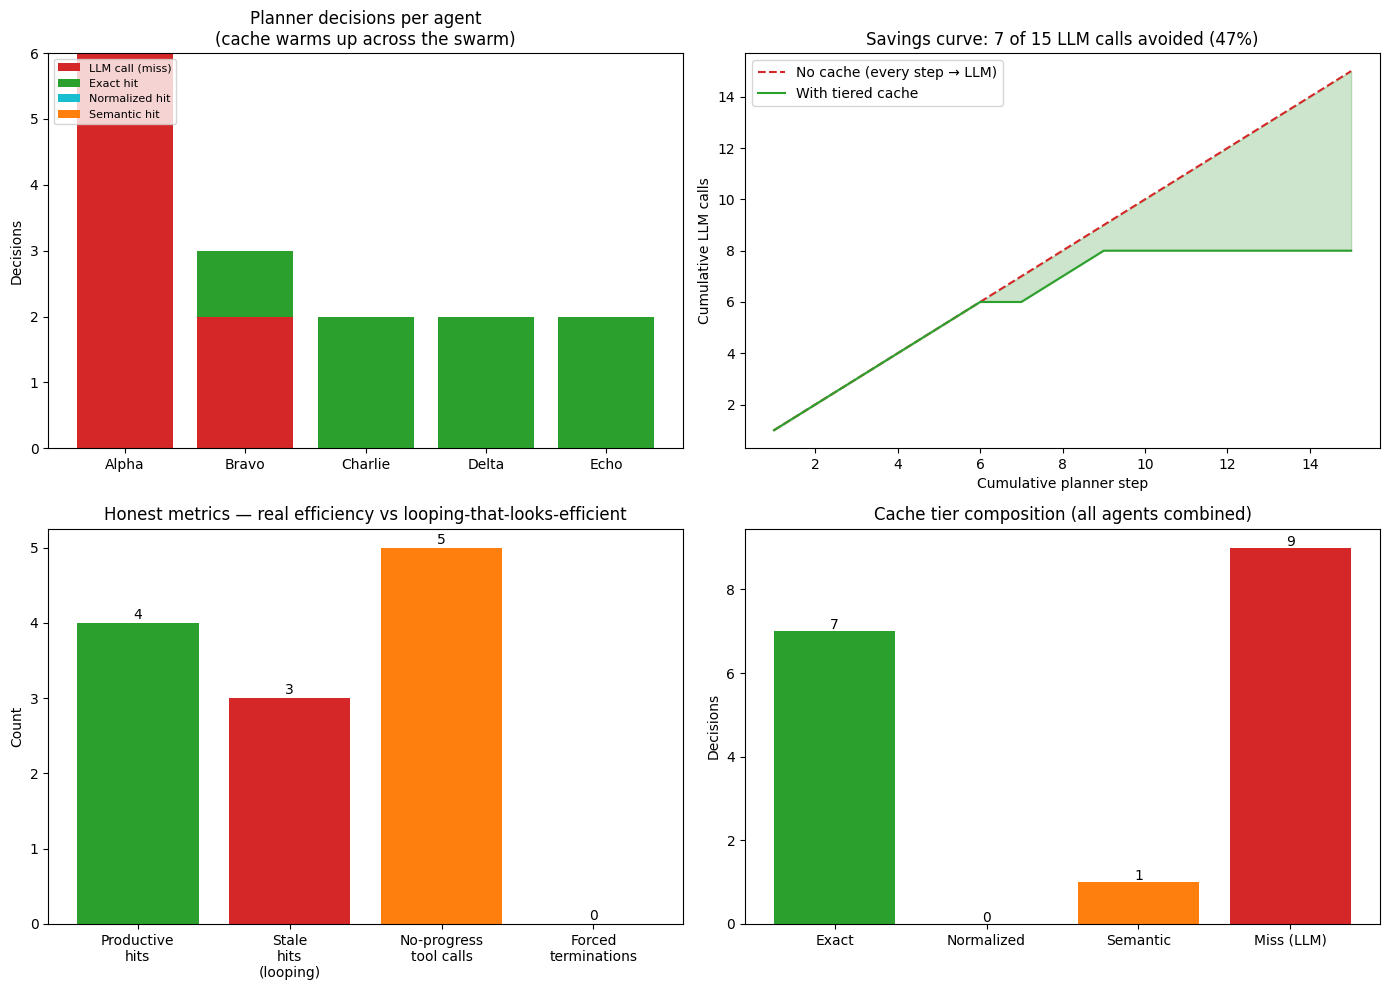

In [ ]:
# Run the swarm and visualize the cache win.
# This makes live LLM + Tavily calls — make sure your .env keys are set.
%matplotlib inline
import matplotlib.pyplot as plt
from collections import Counter

report = run_swarm()
print_report(report)

# ---------- Plots ----------

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Per-agent decision breakdown (stacked bar) — shows the cache warming up.
agents = [t["agent"] for t in report["traces"]]
tier_order = ["LLM call (miss)", "Exact hit", "Normalized hit", "Semantic hit"]
colors = {
    "LLM call (miss)":  "#d62728",
    "Exact hit":        "#2ca02c",
    "Normalized hit":   "#17becf",
    "Semantic hit":     "#ff7f0e",
}
breakdown = {k: [] for k in tier_order}
for t in report["traces"]:
    counts = Counter()
    for d in t["decisions"]:
        if d["chosen_tool"] == "SYNTHESIZE":
            continue
        counts[d["cache_tier"] if d["cached"] else "miss"] += 1
    breakdown["LLM call (miss)"].append(counts["miss"])
    breakdown["Exact hit"].append(counts["exact"])
    breakdown["Normalized hit"].append(counts["normalized"])
    breakdown["Semantic hit"].append(counts["semantic"])

ax = axes[0, 0]
bottom = [0] * len(agents)
for label in tier_order:
    vals = breakdown[label]
    ax.bar(agents, vals, bottom=bottom, label=label, color=colors[label])
    bottom = [b + v for b, v in zip(bottom, vals)]
ax.set_title("Planner decisions per agent\n(cache warms up across the swarm)")
ax.set_ylabel("Decisions")
ax.legend(loc="upper left", fontsize=8)

# 2. Cumulative LLM calls vs cumulative steps — the savings curve.
ax = axes[0, 1]
xs, llm_y, total_y = [], [], []
running_llm = running_total = 0
for t in report["traces"]:
    for d in t["decisions"]:
        if d["chosen_tool"] == "SYNTHESIZE":
            continue
        running_total += 1
        if not d["cached"]:
            running_llm += 1
        xs.append(running_total)
        llm_y.append(running_llm)
        total_y.append(running_total)
saved = running_total - running_llm
ax.plot(xs, total_y, label="No cache (every step → LLM)", color="#d62728", linestyle="--")
ax.plot(xs, llm_y,   label="With tiered cache",          color="#2ca02c")
ax.fill_between(xs, llm_y, total_y, alpha=0.2, color="green")
ax.set_xlabel("Cumulative planner step")
ax.set_ylabel("Cumulative LLM calls")
ax.set_title(f"Savings curve: {saved} of {running_total} LLM calls avoided "
             f"({saved / max(1, running_total) * 100:.0f}%)")
ax.legend()

# 3. Honest metrics — useful work vs looping.
ax = axes[1, 0]
labels = ["Productive\nhits", "Stale\nhits\n(looping)",
          "No-progress\ntool calls", "Forced\nterminations"]
values = [report["productive_cache_hits"], report["stale_cache_hits"],
          report["no_progress_steps"],   report["forced_terminations"]]
bars = ax.bar(labels, values, color=["#2ca02c", "#d62728", "#ff7f0e", "#9467bd"])
ax.set_title("Honest metrics — real efficiency vs looping-that-looks-efficient")
ax.set_ylabel("Count")
for bar, v in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.05,
            str(v), ha="center", fontsize=10)

# 4. Cache tier composition — where do the hits actually come from?
ax = axes[1, 1]
tiers = ["Exact", "Normalized", "Semantic", "Miss (LLM)"]
counts = [report["cache_exact_hits"], report["cache_normalized_hits"],
          report["cache_semantic_hits"], report["cache_misses"]]
bars = ax.bar(tiers, counts, color=["#2ca02c", "#17becf", "#ff7f0e", "#d62728"])
ax.set_title("Cache tier composition (all agents combined)")
ax.set_ylabel("Decisions")
for bar, c in zip(bars, counts):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.05,
            str(c), ha="center", fontsize=10)

plt.tight_layout()
plt.show()


## How to pick the similarity threshold

The default `similarity_threshold = 0.90` was chosen to be conservative — high enough to avoid false positives in the demo, low enough to catch the obvious paraphrases. In a real system you tune this on labeled data.

The cell below builds three groups of fact sets covering different topics (pricing, patents, supply chain). Within each group the sets express the **same underlying facts** in different language; across groups they're **about different things**. We embed each set once, then sweep the threshold and measure:

- **True positive rate (recall):** within-group pairs we successfully cache-match.
- **False positive rate:** across-group pairs we incorrectly cache-match — every one of these is a planner getting the wrong cached decision.

A useful threshold maximizes recall while keeping FPR near zero. Where that knee falls depends on your fact distribution — the sweep is how you find it for *your* workload.


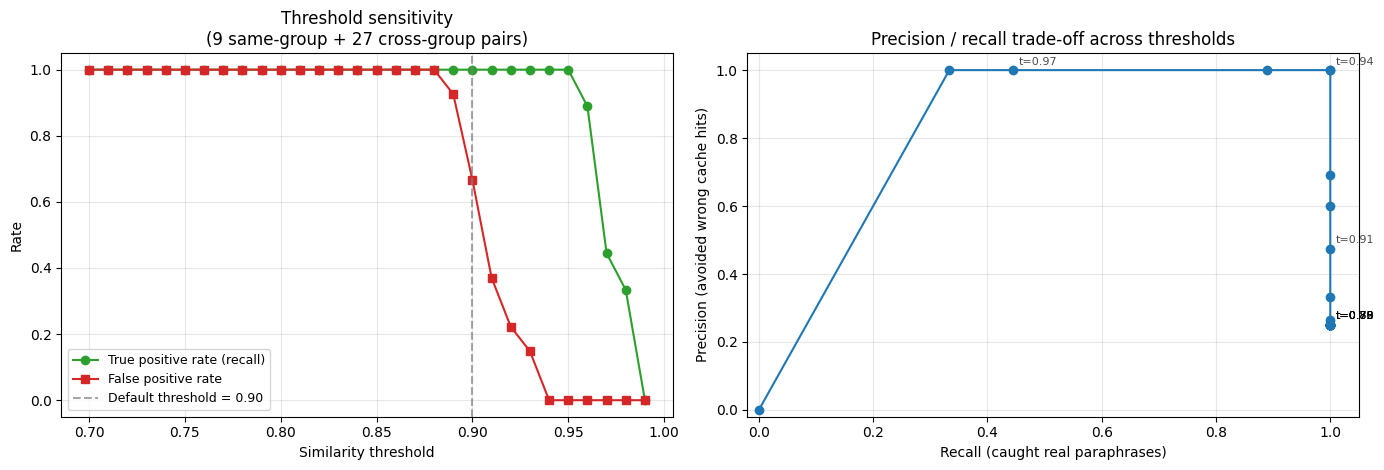

At default threshold 0.90: TPR=1.00, FPR=0.67, precision=0.33
If you see false-positive cache hits in production, raise the threshold.
If you see obvious paraphrases missing the cache, lower it.


In [ ]:
# Threshold sensitivity sweep — no LLM calls, just embeddings.
import numpy as np
import matplotlib.pyplot as plt

# Three topical groups. Within a group: same facts, different surface form.
# Across groups: different topics — should NOT cache-match.
LABELED_GROUPS = {
    "pricing": [
        frozenset([
            Fact("price_point", "$50k", "Sales", 0.9),
            Fact("battery_cycles", "1200 cycles", "Lab", 0.95),
        ]),
        frozenset([
            Fact("msrp_usd", 50000, "InternalDB", 0.95),
            Fact("cycle_life_count", 1200, "TestingDB", 0.95),
        ]),
        frozenset([
            Fact("sticker_price", "fifty thousand dollars", "Press", 0.7),
            Fact("cycle_durability", "1200 charge cycles", "Spec", 0.9),
        ]),
    ],
    "patents": [
        frozenset([
            Fact("active_patents", 47, "USPTO", 0.9),
            Fact("recent_filings_18mo", 12, "USPTO", 0.9),
        ]),
        frozenset([
            Fact("patent_count", 47, "PatentDB", 0.9),
            Fact("recent_patent_apps", 12, "PatentDB", 0.9),
        ]),
        frozenset([
            Fact("granted_patents", 47, "Filings", 0.9),
            Fact("filings_last_18_months", 12, "Filings", 0.9),
        ]),
    ],
    "supply_chain": [
        frozenset([
            Fact("tier1_supplier_count", 3, "SCM", 0.9),
            Fact("lead_time_weeks", 14, "SCM", 0.9),
        ]),
        frozenset([
            Fact("primary_suppliers", 3, "Logistics", 0.9),
            Fact("delivery_lead_weeks", 14, "Logistics", 0.9),
        ]),
        frozenset([
            Fact("vendor_count_tier1", 3, "Procurement", 0.9),
            Fact("avg_lead_time", "14 weeks", "Procurement", 0.9),
        ]),
    ],
}

task = "Evaluate the competitive threat of the 'SolidState Gen 2' battery."
embeddings = OpenAIEmbeddings(model="text-embedding-3-small",
                              openai_api_key=OPENAI_API_KEY)

# Embed each set once (24 embedding calls total).
labeled_vecs = []
for group, sets in LABELED_GROUPS.items():
    for facts in sets:
        ctx = PlannerContext.make(task, WorldView.from_facts(facts),
                                  tools_available=[], stale_tools=[])
        text = TieredCache._facts_to_text(ctx)
        v = np.array(embeddings.embed_query(text), dtype=np.float32)
        labeled_vecs.append((group, v))

def cosine(a, b):
    d = np.linalg.norm(a) * np.linalg.norm(b)
    return float(np.dot(a, b) / d) if d > 0 else 0.0

# Pre-compute pairwise similarity + within-group label
pairs = []
for i in range(len(labeled_vecs)):
    for j in range(i + 1, len(labeled_vecs)):
        gi, vi = labeled_vecs[i]
        gj, vj = labeled_vecs[j]
        pairs.append((gi == gj, cosine(vi, vj)))

n_same = sum(1 for s, _ in pairs if s)
n_diff = sum(1 for s, _ in pairs if not s)

# Sweep threshold
thresholds = np.arange(0.70, 0.99, 0.01)
tpr, fpr, precision, recall = [], [], [], []
for t in thresholds:
    tp = sum(1 for s, sim in pairs if s     and sim >= t)
    fp = sum(1 for s, sim in pairs if not s and sim >= t)
    fn = sum(1 for s, sim in pairs if s     and sim <  t)
    tpr.append(tp / max(1, n_same))
    fpr.append(fp / max(1, n_diff))
    precision.append(tp / max(1, tp + fp))
    recall.append(tp / max(1, tp + fn))

# ---- Plots ----
fig, axes = plt.subplots(1, 2, figsize=(14, 4.8))

ax = axes[0]
ax.plot(thresholds, tpr, marker="o", label="True positive rate (recall)", color="#2ca02c")
ax.plot(thresholds, fpr, marker="s", label="False positive rate",         color="#d62728")
ax.axvline(0.90, color="grey", linestyle="--", alpha=0.7,
           label="Default threshold = 0.90")
ax.set_xlabel("Similarity threshold")
ax.set_ylabel("Rate")
ax.set_title(f"Threshold sensitivity\n({n_same} same-group + {n_diff} cross-group pairs)")
ax.legend(fontsize=9)
ax.grid(alpha=0.3)

ax = axes[1]
ax.plot(recall, precision, marker="o", color="#1f77b4")
for k in range(0, len(thresholds), 3):
    ax.annotate(f"t={thresholds[k]:.2f}", (recall[k], precision[k]),
                fontsize=8, alpha=0.7,
                xytext=(4, 4), textcoords="offset points")
ax.set_xlabel("Recall (caught real paraphrases)")
ax.set_ylabel("Precision (avoided wrong cache hits)")
ax.set_title("Precision / recall trade-off across thresholds")
ax.set_xlim(-0.02, 1.05)
ax.set_ylim(-0.02, 1.05)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

default_idx = int(np.argmin(np.abs(thresholds - 0.90)))
print(f"At default threshold 0.90: TPR={tpr[default_idx]:.2f}, "
      f"FPR={fpr[default_idx]:.2f}, "
      f"precision={precision[default_idx]:.2f}")
print("If you see false-positive cache hits in production, raise the threshold.")
print("If you see obvious paraphrases missing the cache, lower it.")
